# Tutorial 4 — Visualisation

This tutorial covers the publication-ready figures in `scads_drvi.pl`, plus DRVI's own
figures over the same result object:

| figure | function | what it shows |
|---|---|---|
| Heritability landscape | `heritability_landscape` | ranked z-scores + volcano |
| Trait concordance | `trait_concordance` | two-trait scatter |
| UMAP (categorical) | `umap_categorical` | cell-type labels on embedding |
| UMAP (continuous) | `umap_continuous` | score values on embedding |
| Factor diagnostics | `drvi.utils.pl.*` | vanished/order/title stats, per-factor UMAP grid (DRVI-native — no longer reimplemented here) |
| Score by group | `score_by_group` | box plot over cell types |
| Grouped landscape | `grouped_landscape` | cell-type × tissue score heatmap |

We continue from Tutorial 3's synthetic plant dataset.

## 0. Shared setup — reproduce Tutorial 3, plus a UMAP embedding

In [1]:
import tempfile
from pathlib import Path

import anndata as ad
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scads_drvi.enrich.config import kept_dims, latent_stats_from_embed, select_factors
from scads_drvi.enrich.ldsc import read_results
from scads_drvi.io.artifacts import cell_metadata
from scads_drvi.io.result import (
    attach_enrich_results,
    build_embed,
    directional_loadings,
    read_result,
    write_result,
)
from scads_drvi.pl.save import SaveSpec, save_figure
from scads_drvi.pl.style import apply_style
from scads_drvi.scores.aggregate import block_order, group_matrix, summarize_by
from scads_drvi.scores.cell import cs_from_z

apply_style()

TISSUES = ("leaf", "root", "stem", "flower")
LINEAGES = ("mesophyll", "epidermis", "vasculature")
FINE_TYPES = {
    "mesophyll": ("meso_1", "meso_2", "meso_3"),
    "epidermis": ("epi_1", "epi_2"),
    "vasculature": ("vasc_1", "vasc_2", "vasc_3"),
}
CULTIVARS = ("cv_alpha", "cv_beta", "cv_gamma")
TRAITS = ("plant_height", "grain_yield")
N_CELLS, N_FACTORS, N_KEPT = 3000, 12, 9

root = Path(tempfile.mkdtemp())
rng = np.random.default_rng(0)

fine = [t for lin in LINEAGES for t in FINE_TYPES[lin]]
lineage_of = {t: lin for lin in LINEAGES for t in FINE_TYPES[lin]}
cell_ids = np.array([f"plate{i % 5}:bc{i:05d}".encode() for i in range(N_CELLS)])
fine_codes = rng.integers(0, len(fine), size=N_CELLS).astype(np.int32)
tissue_codes = rng.integers(0, len(TISSUES), size=N_CELLS).astype(np.int32)
cultivar_codes = rng.integers(0, len(CULTIVARS), size=N_CELLS).astype(np.int32)
reads = rng.integers(500, 200_000, size=N_CELLS).astype(np.int64)

obs_path = root / "matrix.h5ad"
with h5py.File(obs_path, "w") as fh:
    obs = fh.create_group("obs")
    obs.attrs["_index"] = "cell_uid"
    obs.attrs["encoding-type"] = "dataframe"
    obs.create_dataset("cell_uid", data=cell_ids)
    for name, codes, cats in (
        ("fine_type", fine_codes, fine),
        ("tissue", tissue_codes, TISSUES),
        ("cultivar", cultivar_codes, CULTIVARS),
    ):
        g = obs.create_group(name)
        g.create_dataset("categories", data=np.array([c.encode() for c in cats]))
        g.create_dataset("codes", data=codes)
    obs.create_dataset("total_reads", data=reads)
    lineage_codes = np.array(
        [LINEAGES.index(lineage_of[fine[c]]) for c in fine_codes], dtype=np.int32
    )
    g = obs.create_group("lineage")
    g.create_dataset("categories", data=np.array([lin.encode() for lin in LINEAGES]))
    g.create_dataset("codes", data=lineage_codes)


class FakeDRVIModel:
    """Stands in for a trained ``scvi.external.DRVI`` (see Tutorial 1) — in a real
    analysis this is ``scads_drvi.factorize.model.load_fit(...)``."""

    def __init__(self, z, vanished):
        self._z = z
        self._vanished = np.asarray(vanished, dtype=bool)

    def get_latent_representation(self, adata=None, indices=None, batch_size=128):
        out = self._z
        if indices is not None:
            out = out[np.asarray(indices)]
        return out

    def set_latent_dimension_stats(
        self, embed, adata=None, datamodule=None, vanished_threshold=0.5
    ):
        embed.var["vanished"] = self._vanished
        embed.var["order"] = np.arange(embed.n_vars)
        embed.var["title"] = [f"DR {i + 1}" for i in range(embed.n_vars)]


obs_frame = cell_metadata(
    obs_path, columns=["fine_type", "tissue", "cultivar", "lineage", "total_reads"]
)
fake_adata = ad.AnnData(X=np.zeros((N_CELLS, 1), dtype=np.float32), obs=obs_frame)

z = rng.normal(0.2, 0.6, size=(N_CELLS, N_FACTORS)).astype(np.float32)
vanished = np.array([False] * N_KEPT + [True] * (N_FACTORS - N_KEPT))
model = FakeDRVIModel(z, vanished)

coords = pd.DataFrame(
    rng.normal(size=(N_CELLS, 2)), index=obs_frame.index, columns=["embed_1", "embed_2"]
)

embed = build_embed(
    model, fake_adata, obs_columns=list(obs_frame.columns), umap=coords
)
fit_path = root / "assembly_v3.h5ad"
write_result(
    fit_path, embed, provenance={"n_latent": N_FACTORS, "fit_name": "assembly_v3"}
)

embed = read_result(fit_path)
stats = latent_stats_from_embed(embed)
fmap = select_factors(stats, list(embed.var_names))
keep = kept_dims(fmap)
annot2dim = {f"k{i + 1}": dim for i, dim in enumerate(keep)}

arm = "assembly_v3_topfrac"
results_root = root / "enrich" / arm / "results"
for trait_index, trait in enumerate(TRAITS):
    trait_dir = results_root / trait
    trait_dir.mkdir(parents=True)
    for slot, annot in enumerate(annot2dim):
        z_score = 4.5 - 0.6 * slot + 0.3 * trait_index
        pd.DataFrame({
            "Category": [f"{annot}L2_0"],
            "Coefficient": [1e-8 * z_score],
            "Coefficient_std_error": [1e-8],
            "Coefficient_z-score": [z_score],
            "n_categories": [40],
            "total_h2": [0.11],
        }).to_csv(trait_dir / f"{annot}.results", sep="\t", index=False)

results = read_results(results_root, traits=TRAITS, annot2dim=annot2dim)
attach_enrich_results(embed, arm, results, factor_selection=fmap)
write_result(fit_path, embed, provenance=embed.uns["provenance"])

# -- reload, exactly as a fresh session would --------------------------------------
embed = read_result(fit_path)
arm_result = embed.uns["enrich"][arm]
primary = arm_result["results"].loc[arm_result["results"]["trait"] == "plant_height"]

loadings = directional_loadings(embed, "pos")[keep]
scores = cs_from_z(loadings, primary, model=arm, trait="plant_height")

cells_frame = embed.obs.copy()
cells_frame["embed_1"] = embed.obsm["X_umap"][:, 0]
cells_frame["embed_2"] = embed.obsm["X_umap"][:, 1]
cells_frame["score"] = scores.values.reindex(cells_frame.index)

print("Setup complete.")

Setup complete.


## 1. Heritability landscape

A two-panel figure: ranked bar chart of z-scores (left) and a volcano plot (right).
Points and bars are coloured by significance class from a `SignificanceRamp`.

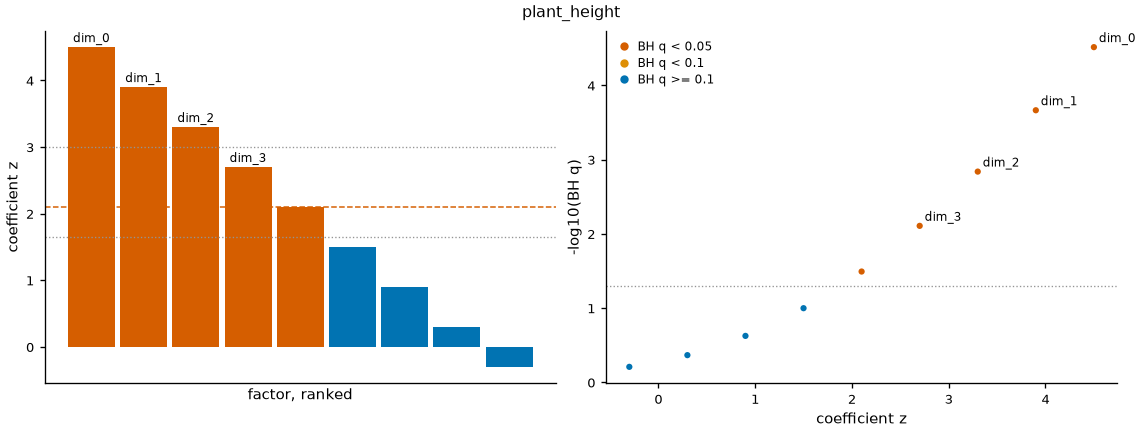

In [2]:
from scads_drvi.pl.enrichment import heritability_landscape

fig, (ax_bar, ax_vol) = heritability_landscape(
    arm_result["results"], trait="plant_height"
)
plt.show()
plt.close()

## 2. Trait concordance

Scatter of z-scores between two traits (left) and a histogram of their difference
(right). Useful for checking whether factors significant for one trait are also active
for another.

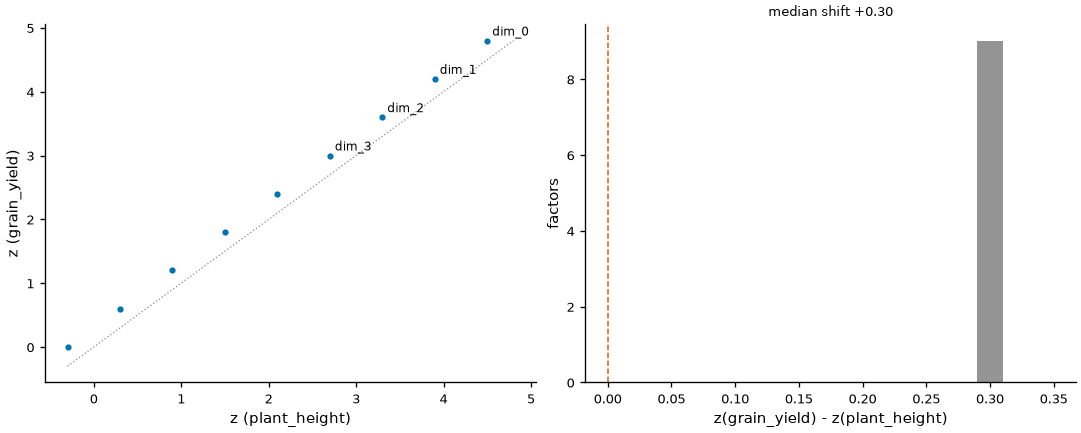

In [3]:
from scads_drvi.pl.enrichment import trait_concordance

fig, _ = trait_concordance(arm_result["results"], traits=list(TRAITS))
plt.show()
plt.close()

## 3. UMAP — categorical and continuous

Both functions accept an optional `ax` argument to embed into an existing figure.
Without it they create their own figure. `x=`/`y=` name the coordinate columns
explicitly — `cells_frame` also carries `total_reads` and `score`, so leaving them to
be auto-detected would pick the wrong two numeric columns.

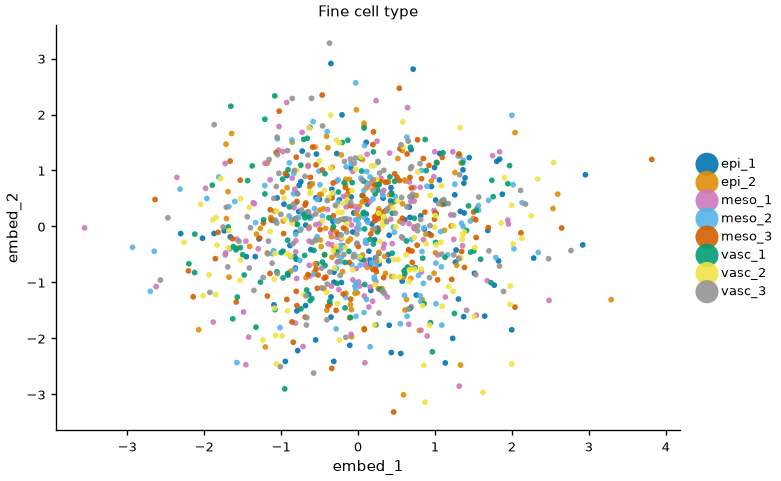

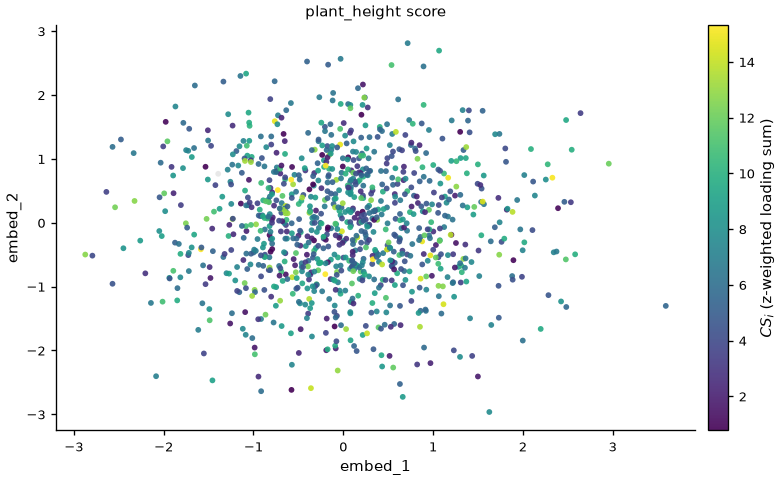

In [4]:
from scads_drvi.pl.umap import umap_categorical, umap_continuous

fig, ax = umap_categorical(cells_frame, "fine_type", x="embed_1", y="embed_2", n=1000)
ax.set_title("Fine cell type")
plt.show()
plt.close()

fig, ax = umap_continuous(
    cells_frame, "score",
    x="embed_1", y="embed_2",
    colorbar_label=scores.label,
    zero_as_background=True,
    n=1000,
)
ax.set_title("plant_height score")
plt.show()
plt.close()

## 4. DRVI's own factor diagnostics (requires the real `drvi` package)

`build_embed` populates `embed.var` and `embed.obsm["X_umap"]` in exactly the shape
DRVI's own interpretability functions expect, so two figures this package used to draw
itself are now DRVI's — `pl.factors.latent_dimension_stats` and
`pl.factors.group_factor_heatmaps`, and the per-factor UMAP grid
`pl.umap.umap_factor_grid`, were all deleted in favour of calling DRVI directly:

```python
import drvi.utils.pl as drvi_pl

# Per-dimension summary statistics (vanished / order / title / ...), driven entirely by
# the `var` columns `model.set_latent_dimension_stats` wrote inside `build_embed`.
drvi_pl.plot_latent_dimension_stats(embed)

# A per-factor grid over the embedding, using `embed.obsm["X_umap"]` and the "order"
# column the real fit's inspection stage assigns.
drvi_pl.plot_latent_dims_in_umap(
    embed, directional=True, dim_subset=keep, order_col="order",
)

# A factor-value-by-category heatmap.
drvi_pl.plot_latent_dims_in_heatmap(embed, categorical_column="fine_type")
```

None of these three calls ran in this notebook: `drvi-py` is a declared dependency of
`scads_drvi` but is not installed in the environment that built these docs. Apply
`scads_drvi.pl.style.apply_style()` / `scads_drvi.pl.save.save_figure()` to whatever
figure they return, the same as any other figure in this package.

## 5. Score by group — frugal box plot

`score_by_group` takes **pre-computed** `BoxStats`, not raw per-cell values.
This separation lets you control ordering, truncation, and highlighting before
committing to the figure.

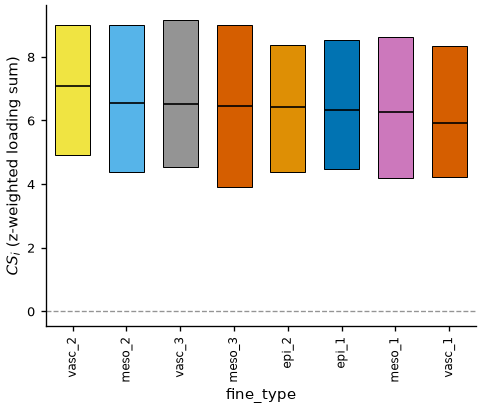

In [5]:
from scads_drvi.pl.enrichment import score_by_group
from scads_drvi.pl.frugal import box_stats

stats = box_stats(
    cells_frame["score"],
    cells_frame["fine_type"].astype(str),
    min_n=10,
    whis="quartile",
)
# Order groups by median descending, highlight the top vascular type
stats = stats.order_by("median", ascending=False)

fig, ax = score_by_group(
    stats,
    group_label="fine_type",
    value_label=scores.label,
    null=scores.null,
    highlight=["vasc_1"],
)
plt.show()
plt.close()

## 6. Grouped landscape — cell-type × tissue heatmap

`grouped_landscape` shows mean score for every (fine type, tissue) combination.
Bins below `min_cells` are masked with `masked_color` (grey by default).

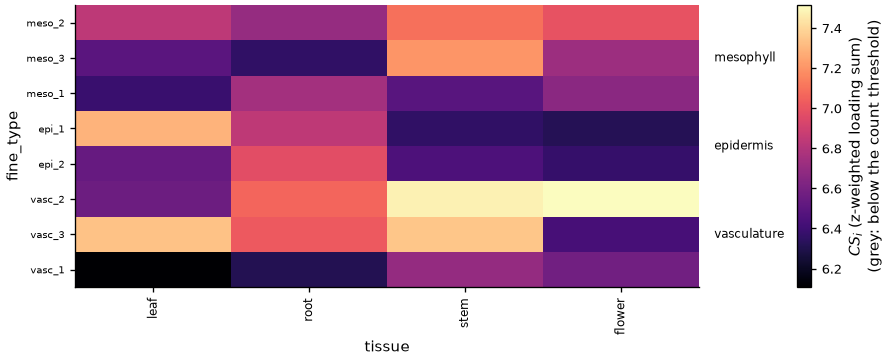

In [6]:
from scads_drvi.pl.enrichment import grouped_landscape

means, counts = group_matrix(
    scores.values, cells_frame,
    index="fine_type", columns="tissue",
    min_cells=10, column_order=list(TISSUES),
)

# Compute block ordering so fine types stay within their lineage
blocked = summarize_by(
    scores.values, cells_frame, by=["lineage", "fine_type"], min_cells=10
)
order, spans = block_order(blocked, group="fine_type", block="lineage")

fig, ax = grouped_landscape(
    means.loc[order],
    counts.loc[order],
    row_label="fine_type",
    column_label="tissue",
    value_label=scores.label,
    blocks=spans,
)
plt.show()
plt.close()

## 7. Saving figures

`save_figure` writes to every format in a `SaveSpec` and returns the list of paths.
It also embeds provenance metadata (timestamp, software version) into the PDF.

In [7]:
from scads_drvi.pl.save import figure_metadata

outdir = root / "figures"
spec = SaveSpec(formats=("png", "pdf"), dpi={"png": 200, "pdf": 300}, close=True)
meta = figure_metadata(model=arm, trait="plant_height")

# Re-generate the landscape to save it
fig, _ = heritability_landscape(arm_result["results"], trait="plant_height")
paths = save_figure(fig, "01_landscape", outdir, spec=spec, metadata=meta)

for p in paths:
    print(p.name, f"  {p.stat().st_size:,} bytes")

01_landscape.png   52,951 bytes
01_landscape.pdf   17,098 bytes


## 8. Custom colour palettes

`categorical_palette` builds a stable category → colour map using the Wong (2011)
colourblind-safe palette for up to 8 categories, then samples from `turbo` for more.

In [8]:
from scads_drvi.pl.color import categorical_palette

palette = categorical_palette(
    list(fine),
    highlight="vasc_1",
    highlight_color="#D55E00",
)
print("vasc_1 colour:", palette["vasc_1"])
print("All colours:")
for cat, color in palette.items():
    print(f"  {cat:12s}: {color}")

vasc_1 colour: #D55E00
All colours:
  epi_1       : #0173B2
  epi_2       : #DE8F05
  meso_1      : #CC78BC
  meso_2      : #56B4E9
  meso_3      : #D55E00
  vasc_1      : #D55E00
  vasc_2      : #F0E442
  vasc_3      : #949494
